# Does the apparent top come from our assumptions?

**Times are UTC**, with elapsed hours/days retained. See the [UTC reference](TIME_REFERENCE.md).

The [agent notebook](rational_scenarios.ipynb) produces a baseline top near +31 hours (2026-09-16 17:09:19 UTC). Its initial spending allowance is `initial cohort cash × 0.77 / 24` each hour. A persistently willing cohort can therefore use its initial cash in approximately `24 / 0.77 = 31.17` hours. Sale proceeds and changing willingness complicate that identity, but it is an immediate reason to challenge the timing.

This notebook changes **spending pace** and **valuation horizon**, separately. It uses three common seeds and seven simulation days per setting. The valuation horizon is how far ahead an actor values earnings, not a forced exit date. A peak at the seven-day boundary is unresolved. These settings are not calibrated population probabilities.


In [1]:
from pathlib import Path
from dataclasses import replace,asdict
import sys,json,hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd()/'research'/'standard-exit'] if (p/'rational_model.py').exists())
sys.path.insert(0,str(ROOT))
import model as old
import rational_model as rm
from time_display import utc_at, with_utc, utc_axis
old.EVIDENCE=ROOT/'notebook-evidence'
start=pd.Timestamp(old.snapshot()['timestamp'],unit='s',tz='UTC')
pd.set_option('display.max_columns',None)
print('Frozen snapshot:',utc_at(start))
OUT=ROOT/'agent-results';OUT.mkdir(exist_ok=True)
SEED=20260915
PATHS=3
BASE=rm.Config(days=7)
configs=[]
for pace in [.25,.5,.77,1.5]:
    configs.append(('Spending pace',pace,replace(BASE,speculator_cash_turnover_day=pace)))
for horizon in [7,14,30,60]:
    configs.append(('Valuation horizon',horizon,replace(BASE,valuation_days=horizon)))


Frozen snapshot: 2026-09-15 10:09:19 UTC


In [2]:
rows=[];curves={};audits=[]
for group,setting,c in configs:
    paths=[rm.simulate(c,SEED+j) for j in range(PATHS)]
    fs=[p['frame'] for p in paths];hours=fs[0].hour.to_numpy()
    prices=np.stack([f.price.to_numpy() for f in fs]);mean=prices.mean(axis=0)
    best=int(np.argmax(mean));curve=paths[0]['frame']
    rows.append(dict(experiment=group,setting=setting,peak_of_mean_price_h=float(hours[best]),
        peak_at_boundary=bool(best==len(hours)-1),median_individual_peak_h=float(np.median(hours[np.argmax(prices,axis=1)])),
        mean_peak_price_ratio=float(mean.max()/mean[0]),mean_final_price_ratio=float(mean[-1]/mean[0]),
        mean_licenses=float(np.mean([p['totals']['licenses_bought'] for p in paths])),
        mean_gross_withdrawn=float(np.mean([p['totals']['gross_withdrawn'] for p in paths]))))
    curves[(group,setting)]=mean/mean[0]
    for f in fs:
        audits.append([f.eth_accounting_error.abs().max(),f.token_accounting_error.abs().max(),f.ledger_accounting_error.abs().max()])
    print(group,setting,'complete',flush=True)
table=with_utc(pd.DataFrame(rows),start);display(table)
table.to_csv(OUT/'behavioral-assumption-sensitivity.csv',index=False)
assert np.max(np.array(audits)[:,0])<1e-5
assert np.max(np.array(audits)[:,1])<.02
assert np.max(np.array(audits)[:,2])<1e-5


Spending pace 0.25 complete


Spending pace 0.5 complete


Spending pace 0.77 complete


Spending pace 1.5 complete


Valuation horizon 7 complete


Valuation horizon 14 complete


Valuation horizon 30 complete


Valuation horizon 60 complete


,experiment,setting,peak_of_mean_price_h,peak_at_boundary,median_individual_peak_h,mean_peak_price_ratio,mean_final_price_ratio,mean_licenses,mean_gross_withdrawn,peak_of_mean_price_utc,median_individual_peak_utc
0,Spending pace,0.25,92.0,False,85.0,1.497640,1.078325,700.0,6.828812e+05,2026-09-19 06:09:19 UTC,2026-09-18 23:09:19 UTC
1,Spending pace,0.50,48.0,False,48.0,2.592342,1.444445,700.0,6.270088e+05,2026-09-17 10:09:19 UTC,2026-09-17 10:09:19 UTC
2,Spending pace,0.77,31.0,False,31.0,3.204854,1.393524,700.0,3.840442e+05,2026-09-16 17:09:19 UTC,2026-09-16 17:09:19 UTC
3,Spending pace,1.50,16.0,False,16.0,4.451119,1.095686,700.0,9.557653e+05,2026-09-16 02:09:19 UTC,2026-09-16 02:09:19 UTC
4,Valuation horizon,7.00,31.0,False,31.0,3.257570,1.237844,700.0,8.019760e+05,2026-09-16 17:09:19 UTC,2026-09-16 17:09:19 UTC
5,Valuation horizon,14.00,31.0,False,31.0,3.193431,1.120999,700.0,1.008637e+06,2026-09-16 17:09:19 UTC,2026-09-16 17:09:19 UTC
6,Valuation horizon,30.00,31.0,False,31.0,3.204854,1.393524,700.0,3.840442e+05,2026-09-16 17:09:19 UTC,2026-09-16 17:09:19 UTC
7,Valuation horizon,60.00,31.0,False,31.0,3.210515,1.413957,700.0,9.069752e+05,2026-09-16 17:09:19 UTC,2026-09-16 17:09:19 UTC


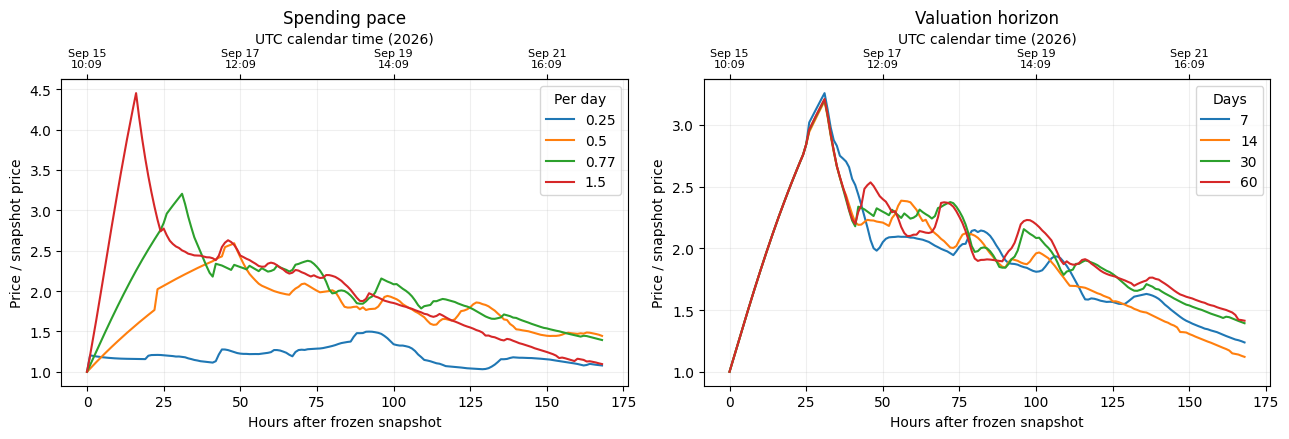

14961

In [3]:
fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for ax,group in zip(axes,['Spending pace','Valuation horizon']):
    for (g,setting),curve in curves.items():
        if g==group:ax.plot(hours,curve,label=str(setting))
    ax.set(xlabel='Hours after frozen snapshot',ylabel='Price / snapshot price',title=group)
    ax.grid(alpha=.2);ax.legend(title='Per day' if group=='Spending pace' else 'Days');utc_axis(ax,start)
fig.tight_layout();fig.savefig(OUT/'behavioral-assumption-sensitivity.png',dpi=160);plt.show()
metadata=dict(seed=SEED,paths=PATHS,simulation_days=BASE.days,
    configurations=[dict(experiment=g,setting=s,config=asdict(c)) for g,s,c in configs],
    source_sha256={n:hashlib.sha256((ROOT/n).read_bytes()).hexdigest() for n in ['rational_model.py','model.py','liquidity.py','time_display.py']},
    evidence_sha256={n:hashlib.sha256((old.EVIDENCE/n).read_bytes()).hexdigest() for n in ['home.json','state.json','charters.json','liquidity-ticks.json','liquidity-positions.json']},
    max_accounting_errors=dict(zip(['ETH','physical_tokens','ledger'],np.max(audits,axis=0).tolist())))
(OUT/'assumption-audit-metadata.json').write_text(json.dumps(metadata,indent=2,allow_nan=False)+'\n')


## Interpretation

A change in the top after changing spending pace means the original date depends on the imposed participation constraint. That is useful for identifying the variable to measure; it does not validate any one pace. Extending the valuation horizon can also change license willingness, retirement and subsequent flow.

All settings reuse the same actual liquidity, tax rules, branch caps and frozen population. No extra capital enters, and locked LP remains safe. The model still does not solve self-consistent beliefs or the full multiplayer equilibrium. Read [the findings](AGENT_FINDINGS.md) alongside these results.
